# Team orienteering beats a single optimized rep

**Claim:** when a rep's shift is time-limited, one *optimally* routed rep leaves profit on the
table. Adding reps (Team Orienteering) collects **strictly more total profit** from the same
territory — and the gain is monotone in team size until the whole territory is covered.

## Why this is a routing fact, not a modelling trick

Phase 10 turned the router into an explicit **Orienteering Problem (OP)**: each rep has a hard
shift-time **budget** `B`, and the solver keeps the most valuable walkable subset it can finish in
time (dropping far, low-value doors). With `num_vehicles = k` it becomes the **Team Orienteering
Problem (TOP)**: `k` reps, each budget-bounded, and a single `AddDisjunction` per door so **no two
reps serve the same door**.

If the total work to serve every worthwhile door exceeds one rep's budget, a lone rep *must* drop
profit. Each additional rep unlocks another `B` of collection capacity, so total collected profit
rises with `k` until it saturates at the territory's ceiling.

This notebook demonstrates it end-to-end on the real pipeline: doors are priced by the **actual
reward model** (bandit-weighted `q(x, a)`), placed on a spread territory, and routed with
`solve_tsp_profits` for `k = 1, 2, 3, 4`. All flags stay off elsewhere; we only vary `num_vehicles`
and the per-rep budget, both introduced in [Phase 10](../plans/phase-10-orienteering.md).

In [ ]:
import sys
import tempfile
from pathlib import Path

import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt

# Make `src/` and `scripts/` importable regardless of where the kernel launched.
ROOT = Path.cwd().resolve()
while ROOT.name != "nba" and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "scripts"))

from nba.api.store import EventStore  # noqa: E402
from nba.bandits.epsilon_greedy import EpsilonGreedy  # noqa: E402
from nba.config import Settings  # noqa: E402
from nba.data.ames import load_ames  # noqa: E402
from nba.data.drift import generate_logs_for_settings  # noqa: E402
from nba.data.simulator import sample_context  # noqa: E402
from nba.pipeline.orchestrator import Orchestrator, build_distance_engine  # noqa: E402
from nba.reward.model import RewardModel  # noqa: E402
from nba.routing.tsp_profits import solve_tsp_profits  # noqa: E402

: 

## 1. Parameters

A **spread** territory (not a single dense block) is the point: reps must traverse it, so one rep's
budget cannot cover everything. Six door-clusters sit on a ring around a central depot; each cluster
is walkable internally, but the ring is not walkable within one short shift.

- `SHIFT_HOURS` is the per-rep budget `B` (the OP constraint). It is deliberately short so a lone
  rep is capacity-limited.
- `DROP_SCALE` converts a door's expected reward into the integer drop penalty the solver trades
  against travel seconds. On a spread territory a conversion is worth a lot of walking, so it is
  higher than the dense-block default (`1000`).
- `TEAM_SIZES` is the sweep we compare.

In [2]:
SEED = 7

# Territory geometry
DEPOT = (42.03, -93.62)  # rep start/end (territory centroid)
N_CLUSTERS = 6
DOORS_PER_CLUSTER = 10
RING_KM = 1.2  # cluster centers sit this far from the depot
CLUSTER_RADIUS_KM = 0.10  # doors scatter within this of their cluster center

# Routing / shift
SHIFT_HOURS = 1.5  # per-rep budget B (short => a lone rep is constrained)
DROP_SCALE = 20_000.0  # value of serving a door, in penalty-per-unit-reward
SERVICE_TIME_S = 120.0  # dwell per door (knock + pitch)
TEAM_SIZES = [1, 2, 3, 4]

N_DOORS = N_CLUSTERS * DOORS_PER_CLUSTER
N_LOGS = 2500  # logs used to fit the reward model that prices doors

_LAT_PER_KM = 1.0 / 111.2
_LON_PER_KM = 1.0 / (111.2 * np.cos(np.radians(DEPOT[0])))
print(f"{N_DOORS} doors across {N_CLUSTERS} clusters; per-rep budget B = {SHIFT_HOURS} h")

60 doors across 6 clusters; per-rep budget B = 1.5 h


## 2. Price the doors with the real reward model

We fit the calibrated LightGBM reward model on simulated logs and wrap it in an epsilon-greedy
bandit — exactly the serve path. Each door's **prize** is the orchestrator's bandit-weighted value
`door_profit(ctx) = Σ_a π(a|x) · q(x, a)`, so the prizes are the same numbers the router sees in
production, not hand-picked values.

In [3]:
settings = Settings()
rng = np.random.default_rng(SEED)

events, _ = generate_logs_for_settings(N_LOGS, settings=settings, seed=SEED)
model = RewardModel.fit(events, settings=settings)

# A throwaway store so we never touch artifacts/events.db (we only call door_profit, no writes).
_tmp = tempfile.TemporaryDirectory(prefix="nba-team-demo-")
orch = Orchestrator(
    policy=EpsilonGreedy(model, epsilon=settings.epsilon, rng=rng),
    reward_model=model,
    distance_engine=build_distance_engine(settings),
    store=EventStore(Path(_tmp.name) / "events.db"),
    settings=settings,
)
print(f"reward model fitted on {len(events)} logged events")

reward model fitted on 2500 logged events


/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 3. Build the spread territory

Sample real prospect contexts (Ames/ACS-backed), then reposition them onto the cluster ring. Since
`lat`/`lon` are excluded from every model by the ethics allow-list, moving doors changes geography
only — never a door's reward, prize, or outcome. Node `0` is the depot; nodes `1..N` are doors.

In [4]:
ames = load_ames(settings, seed=SEED)
rows = ames.sample(n=N_DOORS, replace=True, random_state=SEED).reset_index(drop=True)
base_contexts = [sample_context(rows.iloc[i].to_dict(), rng) for i in range(N_DOORS)]

doors = []
cluster_of = []
i = 0
for c in range(N_CLUSTERS):
    ang = 2.0 * np.pi * c / N_CLUSTERS
    cc_lat = DEPOT[0] + RING_KM * np.sin(ang) * _LAT_PER_KM
    cc_lon = DEPOT[1] + RING_KM * np.cos(ang) * _LON_PER_KM
    for _ in range(DOORS_PER_CLUSTER):
        r = CLUSTER_RADIUS_KM * np.sqrt(rng.random())  # sqrt => uniform over the disk
        t = rng.uniform(0.0, 2.0 * np.pi)
        lat = cc_lat + r * np.sin(t) * _LAT_PER_KM
        lon = cc_lon + r * np.cos(t) * _LON_PER_KM
        doors.append(base_contexts[i].model_copy(update={"lat": lat, "lon": lon}))
        cluster_of.append(c)
        i += 1

# coords[0] = depot; prizes[0] = 0 (depot has no reward). Prizes come from the real reward model.
coords = [DEPOT, *[(d.lat, d.lon) for d in doors]]
prizes = [0.0, *[orch.door_profit(d) for d in doors]]
time_matrix = build_distance_engine(settings).time_matrix(coords)

total_prize = float(sum(prizes))
print(f"total prize on the table = {total_prize:.2f}  (mean door = {np.mean(prizes[1:]):.3f})")

total prize on the table = 6.33  (mean door = 0.105)


/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

## 4. Route the same territory with `k = 1..4` reps

Everything is held fixed — same doors, same prizes, same per-rep budget `B` — and only
`num_vehicles` changes. For `k > 1` the solver returns one route per rep; we sum the collected
prize across reps. Because reps walk in parallel, the shift wall-clock is the **slowest** rep, which
we confirm stays within `B`.

In [5]:
budget_s = SHIFT_HOURS * 3600.0
results = {}
for k in TEAM_SIZES:
    solved = solve_tsp_profits(
        coords,
        prizes,
        time_matrix,
        capacity=None,
        route_budget_s=budget_s,
        num_vehicles=k,
        drop_scale=DROP_SCALE,
        service_time_s=SERVICE_TIME_S,
        time_limit_s=3.0,
        seed=SEED,
    )
    routes = solved if isinstance(solved, list) else [solved]
    results[k] = {
        "routes": routes,
        "profit": sum(r.total_profit for r in routes),
        "served": sum(len(r.visited) for r in routes),
        "max_time_min": max(r.total_time_s for r in routes) / 60.0,
    }

print(f"per-rep budget B = {SHIFT_HOURS*60:.0f} min\n")
for k in TEAM_SIZES:
    r = results[k]
    print(
        f"k={k}  profit={r['profit']:6.2f} / {total_prize:.2f}  "
        f"served={r['served']:2d}/{N_DOORS}  slowest rep={r['max_time_min']:5.1f} min"
    )

per-rep budget B = 90 min

k=1  profit=  1.84 / 6.33  served=18/60  slowest rep= 89.5 min
k=2  profit=  3.65 / 6.33  served=35/60  slowest rep= 89.7 min
k=3  profit=  5.74 / 6.33  served=53/60  slowest rep= 90.0 min
k=4  profit=  6.33 / 6.33  served=60/60  slowest rep= 88.9 min


## 5. The result: profit rises with team size, budget always respected

We assert the two claims the demo is meant to prove:

1. **Monotone lift** — total collected profit is non-decreasing in `k`, and a 2-rep team strictly
   beats the single optimized rep.
2. **Every route is feasible** — no rep exceeds the shift budget `B` (that is what makes the
   single-rep number a *hard ceiling*, not laziness).

In [6]:
profit_by_k = [results[k]["profit"] for k in TEAM_SIZES]
budget_min = SHIFT_HOURS * 60.0

# 1. Monotone in team size, and a real team (>=2) beats the lone rep.
assert all(b >= a - 1e-9 for a, b in zip(profit_by_k, profit_by_k[1:])), profit_by_k
assert results[2]["profit"] > results[1]["profit"] + 1e-6, "team must beat one rep"

# 2. No rep ever exceeds the shift budget (tolerance for integer travel-time rounding).
for k in TEAM_SIZES:
    for r in results[k]["routes"]:
        assert r.total_time_s <= budget_s + len(r.order), (k, r.total_time_s)

lift = results[2]["profit"] / results[1]["profit"] - 1.0
print(f"one optimized rep collects {results[1]['profit']:.2f}")
print(f"two reps collect          {results[2]['profit']:.2f}  (+{lift*100:.0f}% vs one rep)")
print(f"territory ceiling         {total_prize:.2f}")
print("\nchecks passed: profit is monotone in team size and every rep is within budget.")

one optimized rep collects 1.84
two reps collect          3.65  (+98% vs one rep)
territory ceiling         6.33

checks passed: profit is monotone in team size and every rep is within budget.


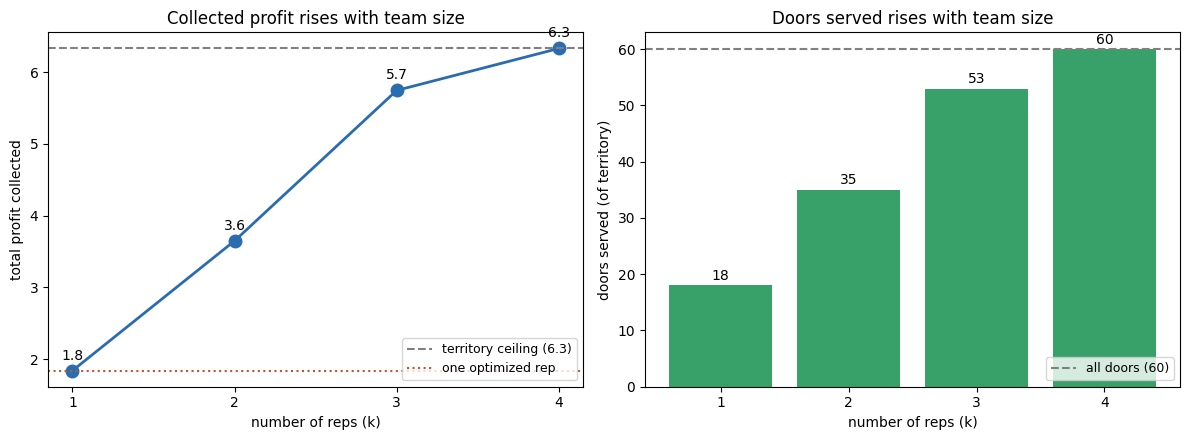

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(TEAM_SIZES, profit_by_k, "o-", lw=2, ms=9, color="#2b6cb0")
ax1.axhline(total_prize, ls="--", color="gray", label=f"territory ceiling ({total_prize:.1f})")
ax1.axhline(results[1]["profit"], ls=":", color="#c05621", label="one optimized rep")
for k, p in zip(TEAM_SIZES, profit_by_k):
    ax1.annotate(f"{p:.1f}", (k, p), textcoords="offset points", xytext=(0, 8), ha="center")
ax1.set_xlabel("number of reps (k)")
ax1.set_ylabel("total profit collected")
ax1.set_title("Collected profit rises with team size")
ax1.set_xticks(TEAM_SIZES)
ax1.legend(loc="lower right", fontsize=9)

served_by_k = [results[k]["served"] for k in TEAM_SIZES]
ax2.bar([str(k) for k in TEAM_SIZES], served_by_k, color="#38a169")
ax2.axhline(N_DOORS, ls="--", color="gray", label=f"all doors ({N_DOORS})")
for k, s in zip(range(len(TEAM_SIZES)), served_by_k):
    ax2.annotate(f"{s}", (k, s), textcoords="offset points", xytext=(0, 4), ha="center")
ax2.set_xlabel("number of reps (k)")
ax2.set_ylabel("doors served (of territory)")
ax2.set_title("Doors served rises with team size")
ax2.legend(loc="lower right", fontsize=9)

plt.tight_layout()

## 6. See it on the map: one rep leaves clusters unserved

The lone rep (left) can only reach the clusters nearest the depot within its shift; distant clusters
are dropped (gray). The team (right) fans out — each rep takes a different slice of the ring — so far
clusters that were pure lost profit for one rep now get served.

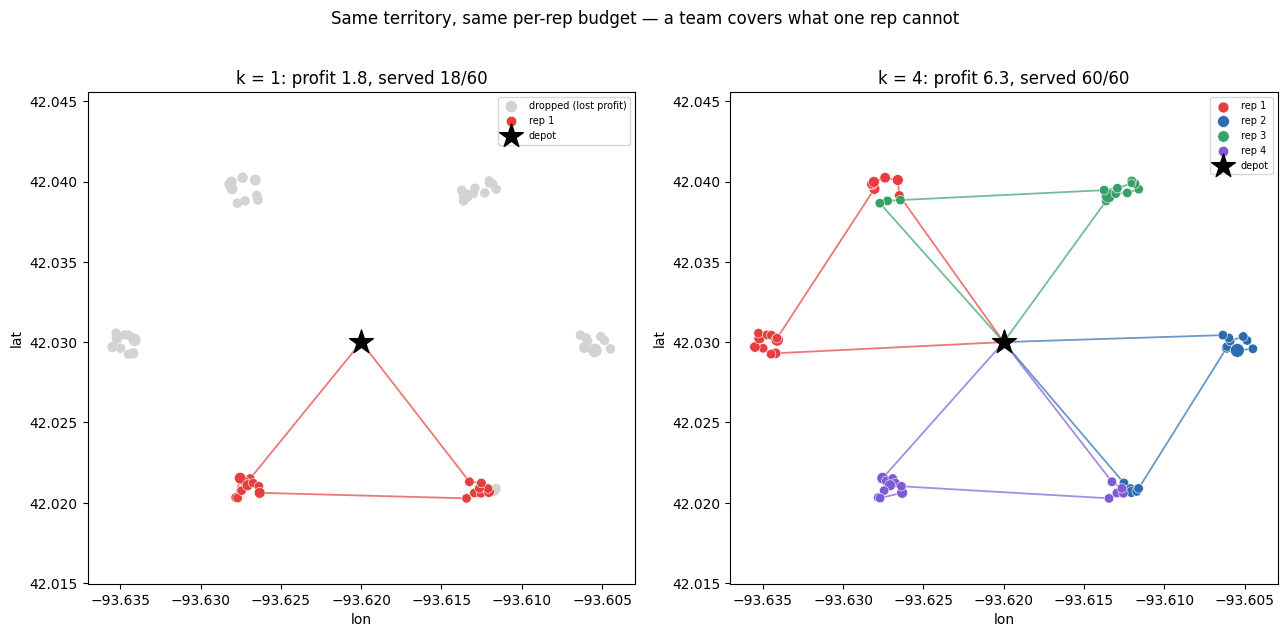

In [8]:
coords_arr = np.array(coords)
prize_arr = np.array(prizes)
rep_colors = ["#e53e3e", "#2b6cb0", "#38a169", "#805ad5", "#dd6b20", "#319795"]


def plot_territory(ax, k):
    routes = results[k]["routes"]
    served_nodes = {n for r in routes for n in r.visited}
    dropped = [n for n in range(1, len(coords)) if n not in served_nodes]

    # Dropped doors in gray, sized by their (lost) prize.
    if dropped:
        ax.scatter(
            coords_arr[dropped, 1], coords_arr[dropped, 0],
            s=20 + 300 * prize_arr[dropped], c="lightgray", edgecolors="none",
            label="dropped (lost profit)", zorder=2,
        )
    # Each rep's path + its visited doors.
    for v, r in enumerate(routes):
        color = rep_colors[v % len(rep_colors)]
        path = coords_arr[r.order]
        ax.plot(path[:, 1], path[:, 0], "-", color=color, lw=1.3, alpha=0.7, zorder=3)
        if r.visited:
            ax.scatter(
                coords_arr[r.visited, 1], coords_arr[r.visited, 0],
                s=20 + 300 * prize_arr[r.visited], c=color, edgecolors="white",
                linewidths=0.4, label=f"rep {v + 1}", zorder=4,
            )
    ax.scatter(DEPOT[1], DEPOT[0], marker="*", s=320, c="black", label="depot", zorder=5)
    ax.set_title(f"k = {k}: profit {results[k]['profit']:.1f}, served {results[k]['served']}/{N_DOORS}")
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")
    ax.legend(loc="upper right", fontsize=7)
    ax.set_aspect("equal", adjustable="datalim")


fig, axes = plt.subplots(1, 2, figsize=(13, 6.2))
plot_territory(axes[0], TEAM_SIZES[0])
plot_territory(axes[1], TEAM_SIZES[-1])
fig.suptitle("Same territory, same per-rep budget — a team covers what one rep cannot", y=1.02)
plt.tight_layout()

## 7. Takeaways

- **Team orienteering strictly dominates a single optimized rep** whenever the territory's total
  work exceeds one rep's shift budget. The single-rep number is a *hard ceiling* — the solver was
  already optimal, it simply ran out of time — so the extra profit from more reps is real, not slack
  recovered by better routing.
- The lift is **monotone in `k`** and saturates once the whole territory is covered; past that,
  extra reps add nothing (spare capacity), which is why `num_vehicles` is a tunable, not a default.
- Prizes here are the **real reward model's** bandit-weighted `q(x, a)`, and `no two reps serve the
  same door` (one `AddDisjunction` per door), so the comparison is faithful to the serve path.
- **Why the Phase 10 leaderboard row was neutral/regression:** the graded demo routes a single dense
  0.3 km block that one rep can fully service within the window, so a second rep is redundant *there*.
  This notebook shows the regime where team routing pays off — a **spread, budget-constrained
  territory** — which is exactly when to flip `NBA_NUM_VEHICLES > 1`.
- Knobs to explore: shrink `SHIFT_HOURS` (tighter budget => bigger team advantage), widen `RING_KM`
  (more travel => one rep covers less), or raise `N_CLUSTERS`.